# Phân tích hội tụ của Robust Risk-Aware Bandit
Notebook này nạp dữ liệu từ các file `.npz` và vẽ đồ thị chi tiết cho từng chỉ số.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re

# 1. Cấu hình
results_root = "results"
n_list = [100, 200, 500, 1000, 2000, 5000, 10000, 20000, 50000]

color_map = {
    'robust': '#ff7f0e',        # Cam
    'quantile_risk': '#1f77b4', # Xanh dương
    'risk_lin_lcb': '#2ca02c',  # Xanh lá (Linear)
    'risk_exact': '#d62728' # Đỏ
}

label_map = {
    'risk_exact': 'Standar Neural',
    'risk_lin_lcb': ' LinLCB (Baseline)'
    'robust'

}

def get_algo_prefixes(data_dir):
    files = glob.glob(os.path.join(data_dir, "*.npz"))
    prefixes = set()
    for f in files:
        basename = os.path.basename(f)
        match = re.match(r"^(.*?)_(robust_syn|mushroom|insulin)_", basename)
        if match:
            prefixes.add(match.group(1))
    return sorted(list(prefixes))

def load_algorithms_from_dir(data_dir, n_list):
    prefixes = get_algo_prefixes(data_dir)
    all_results = {}
    all_files = glob.glob(os.path.join(data_dir, "*.npz"))
    
    for prefix in prefixes:
        summary = {'n_regret': [], 'n_extra': [], 'regret_mean': [], 'regret_std': [], 
                   'subopt_mean': [], 'subopt_std': [], 'gt_cvar_mean': [], 'gt_cvar_std': [],
                   'oracle_cvar': []}
        
        for n in n_list:
            target_files = []
            for f in all_files:
                fname = os.path.basename(f)
                if fname.startswith(prefix) and re.search(fr"_n={n}(_|\.npz)", fname):
                    target_files.append(f)
            
            if not target_files: continue
            d = np.load(target_files[0], allow_pickle=True)
            algo_name = d['algo_names'][0].replace(' ', '_') if 'algo_names' in d else prefix

            def get_d(s): 
                if algo_name and f"{algo_name}_{s}" in d: return d[f"{algo_name}_{s}"]
                return d[s] if s in d else None

            r = get_d('regrets')
            if r is not None:
                summary['n_regret'].append(n)
                summary['regret_mean'].append(np.mean(r))
                summary['regret_std'].append(np.std(r) / np.sqrt(len(r.flatten())))
            
            c = get_d('gt_cvars')
            if c is not None:
                summary['n_extra'].append(n)
                o_cvar = np.mean(d['oracle_cvars'])
                summary['gt_cvar_mean'].append(np.mean(c))
                summary['gt_cvar_std'].append(np.std(c) / np.sqrt(len(c.flatten())))
                sub = o_cvar - c
                summary['subopt_mean'].append(np.mean(sub))
                summary['subopt_std'].append(np.std(sub) / np.sqrt(len(c.flatten())))
                summary['oracle_cvar'].append(o_cvar)
        all_results[prefix] = summary
    return all_results

all_function_data = {}
for dname in os.listdir(results_root):
    if dname.startswith("robust_syn_") and os.path.isdir(os.path.join(results_root, dname)):
        parts = dname.split('_')
        if len(parts) >= 3:
            func_name = parts[2]
            full_path = os.path.join(results_root, dname)
            print(f"Loading data for function: {func_name} from {dname}")
            all_function_data[func_name] = load_algorithms_from_dir(full_path, n_list)
print("Dữ liệu của tất cả thuật toán đã nạp xong!")

Loading data for function: cosine from robust_syn_cosine_d=20_a=30_pi=eps-greedy0.1_std=0.1
Loading data for function: quadratic from robust_syn_quadratic_d=20_a=30_pi=eps-greedy0.1_std=0.1
Loading data for function: linear from robust_syn_linear_d=20_a=30_pi=eps-greedy0.1_std=0.1
Dữ liệu của tất cả thuật toán đã nạp xong!


In [6]:
for func_name, summaries in all_function_data.items():
    plt.figure(figsize=(10, 6))
    for algo, summary in summaries.items():
        print(algo)

quantile_risk
risk_exact
risk_lin_lcb
robust
quantile_risk
risk_exact
risk_lin_lcb
robust
quantile_risk
risk_exact
risk_lin_lcb
robust


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

### 1. Biểu đồ Regret (Hội tụ kỳ vọng)
Kỳ vọng phần thưởng bị mất so với Oracle.

quantile_risk
{'n_regret': [100, 500, 1000, 2000, 5000, 10000, 20000, 50000], 'n_extra': [100, 500, 1000, 2000, 5000, 10000, 20000, 50000], 'regret_mean': [0.19147839, 0.18440053, 0.19385538, 0.19472817, 0.20296061, 0.19829611, 0.18591459, 0.17089471], 'regret_std': [0.002597611984243682, 0.0025413378860418413, 0.005302352590818235, 0.0029948933874898087, 0.005347851449556871, 0.004417717122938412, 0.002675801753842874, 0.002494994077949065], 'subopt_mean': [0.20956406, 0.20139928, 0.21203251, 0.21363735, 0.22241974, 0.21726446, 0.20333628, 0.18522939], 'subopt_std': [0.003059295668760635, 0.0026553209354442577, 0.006236415976109955, 0.003702630211465194, 0.006367850513462509, 0.005185150546490495, 0.0032139853092507387, 0.0027614847428277037], 'gt_cvar_mean': [-4.0511208, -4.0429564, -4.0535893, -4.055194, -4.0639763, -4.0588217, -4.044893, -4.026786], 'gt_cvar_std': [0.003059295668760635, 0.0026553206409342008, 0.006236415976109955, 0.003702630211465194, 0.006367850513462509, 0.00518

risk_exact
{'n_regret': [100, 500, 1000, 5000, 10000, 20000, 50000], 'n_extra': [100, 500, 1000, 5000, 10000, 20000, 50000], 'regret_mean': [0.1960465, 0.19602165, 0.19903593, 0.17704035, 0.17399001, 0.17966051, 0.18493795], 'regret_std': [0.002708956518043539, 0.0027694391649629346, 0.004125395275451792, 0.003375326164872911, 0.003788555876737166, 0.0037599477587997357, 0.001753283310048881], 'subopt_mean': [0.21465397, 0.21533814, 0.21780601, 0.1927497, 0.18899122, 0.19552144, 0.20110174], 'subopt_std': [0.0033710516459025406, 0.003157829604091897, 0.004954016108490178, 0.003816548468655024, 0.004552651028790754, 0.00450445121831743, 0.002300446329846101], 'gt_cvar_mean': [-4.056211, -4.0568953, -4.0593624, -4.0343065, -4.0305476, -4.0370784, -4.0426583], 'gt_cvar_std': [0.0033710519404125975, 0.003157829604091897, 0.004954016108490178, 0.003816548468655024, 0.004552651028790754, 0.00450445121831743, 0.002300446329846101], 'oracle_cvar': [-3.841556854484496, -3.841556854484496, -3.84

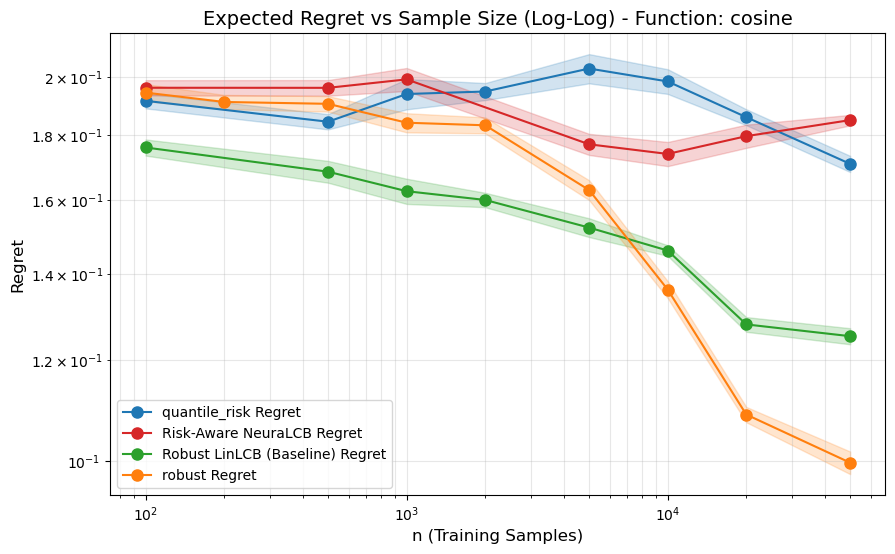

quantile_risk
{'n_regret': [100, 500, 1000, 5000, 10000, 20000, 50000], 'n_extra': [100, 500, 1000, 5000, 10000, 20000, 50000], 'regret_mean': [1.970389, 2.0217757, 2.0153499, 1.6338329, 1.2922692, 0.6829151, 0.26400357], 'regret_std': [0.01710133198467514, 0.007610520974364428, 0.011098540823609282, 0.014767346849513769, 0.013706039804983618, 0.01408737142706133, 0.009923581169960905], 'subopt_mean': [1.9228029, 1.9614818, 1.9539089, 1.6929128, 1.4373214, 0.85607225, 0.34425464], 'subopt_std': [0.012135392931028803, 0.005896585533254287, 0.007440181658454208, 0.011172154201429462, 0.010480520892872354, 0.017304625208927005, 0.011916086605946223], 'gt_cvar_mean': [-4.3794713, -4.41815, -4.4105773, -4.149581, -3.8939896, -3.3127403, -2.800923], 'gt_cvar_std': [0.012135392931028803, 0.005896586122274402, 0.007440181658454208, 0.011172154201429462, 0.010480519714832126, 0.017304625208927005, 0.011916086605946223], 'oracle_cvar': [-2.456668272229259, -2.456668272229259, -2.456668272229259,

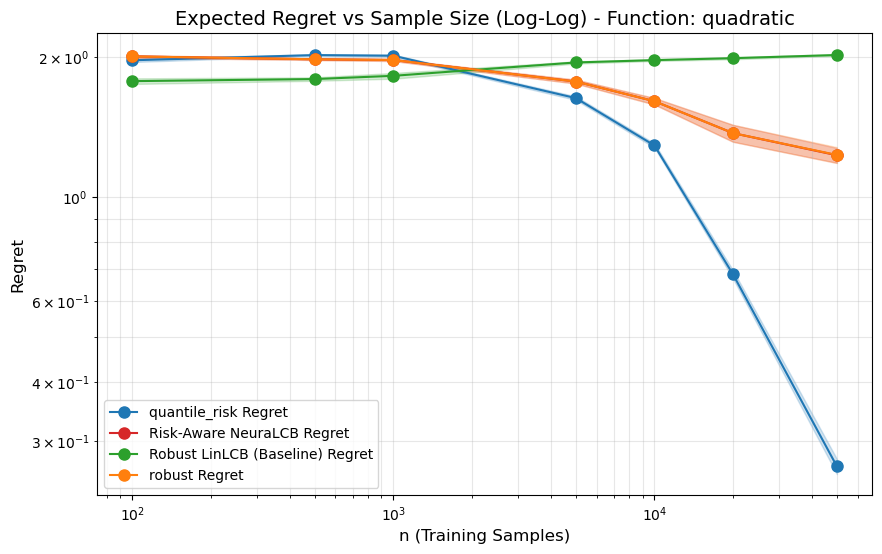

quantile_risk
{'n_regret': [100, 500, 1000, 5000, 10000, 20000, 50000], 'n_extra': [100, 500, 1000, 5000, 10000, 20000, 50000], 'regret_mean': [0.42607135, 0.4331153, 0.42125735, 0.41507164, 0.4222929, 0.42405218, 0.3136682], 'regret_std': [0.004202311878073658, 0.006387372996134958, 0.006089609780831295, 0.005219559334514767, 0.004020845677691924, 0.007908448526280015, 0.01169858150437355], 'subopt_mean': [0.44066668, 0.4463242, 0.43350196, 0.4286707, 0.43578362, 0.43723378, 0.32451853], 'subopt_std': [0.004264897326801545, 0.006485606236697807, 0.005955140611849233, 0.005123348789024848, 0.004048542581512341, 0.007847740579166852, 0.011848496547816136], 'gt_cvar_mean': [-4.8339324, -4.8395905, -4.826768, -4.821937, -4.82905, -4.8305, -4.7177844], 'gt_cvar_std': [0.004264897326801545, 0.006485606236697807, 0.005955140611849233, 0.005123348789024848, 0.004048542581512341, 0.007847739990146738, 0.011848496547816136], 'oracle_cvar': [-4.3932663286055424, -4.3932663286055424, -4.393266328

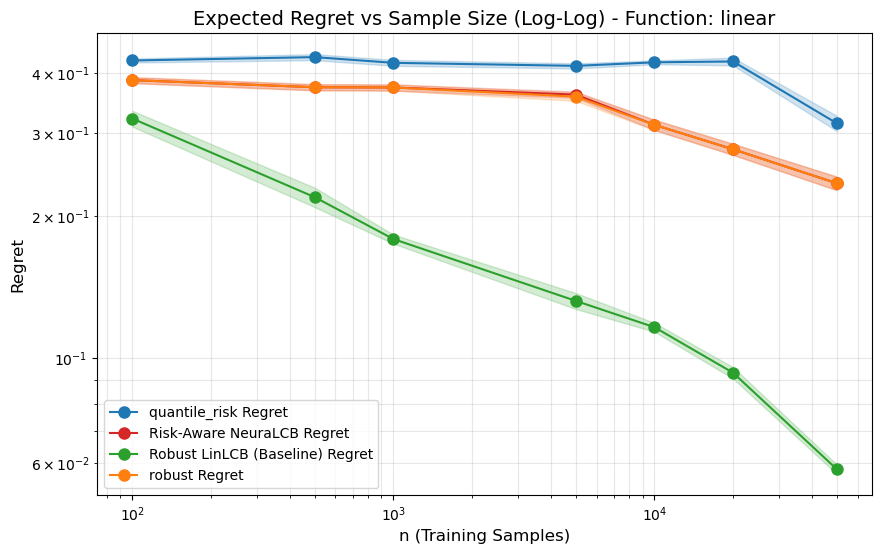

In [7]:
for func_name, summaries in all_function_data.items():
    plt.figure(figsize=(10, 6))
    for algo, summary in summaries.items():
        print(algo)
        if not summary['n_regret']: continue
        color = color_map.get(algo, None)
        print(summary)
        plt.plot(summary['n_regret'], summary['regret_mean'], '-o', label=f"{label_map.get(algo, algo)} Regret", markersize=8, color=color)
        plt.fill_between(summary['n_regret'], 
                         np.array(summary['regret_mean']) - np.array(summary['regret_std']), 
                         np.array(summary['regret_mean']) + np.array(summary['regret_std']), 
                         alpha=0.2, color=color)

    plt.xscale('log'); plt.yscale('log')
    plt.title(f"Expected Regret vs Sample Size (Log-Log) - Function: {func_name}", fontsize=14)
    plt.xlabel("n (Training Samples)", fontsize=12); plt.ylabel("Regret", fontsize=12)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

### 2. Suboptimality Gap (Hội tụ rủi ro CVaR)
Giá trị này tiến về 0 nghĩa là thuật toán học được chính sách tối ưu về mặt rủi ro. Khoảng cách được tính bằng: `Oracle CVaR - Agent CVaR`.

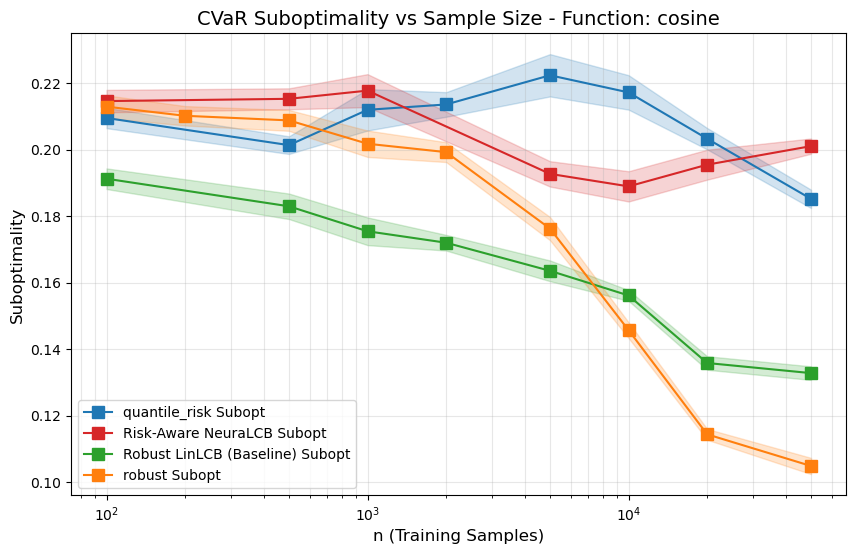

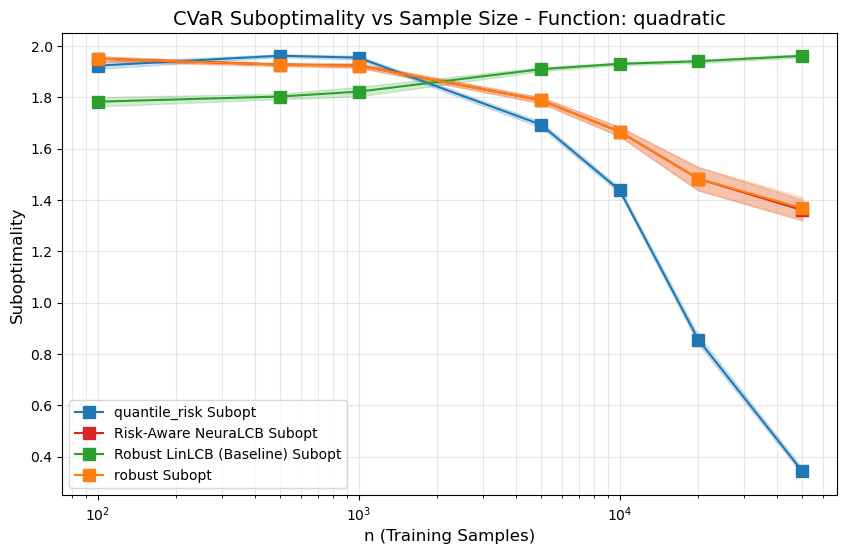

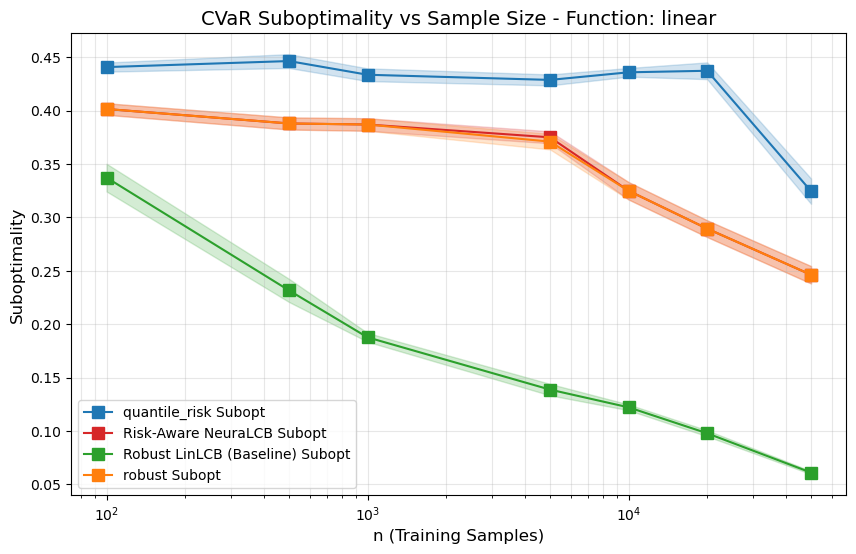

In [8]:
for func_name, summaries in all_function_data.items():
    plt.figure(figsize=(10, 6))
    for algo, summary in summaries.items():
        if not summary['n_extra']: continue
        color = color_map.get(algo, None)
        plt.plot(summary['n_extra'], summary['subopt_mean'], '-s', label=f"{label_map.get(algo, algo)} Subopt", markersize=8, color=color)
        plt.fill_between(summary['n_extra'], 
                         np.array(summary['subopt_mean']) - np.array(summary['subopt_std']), 
                         np.array(summary['subopt_mean']) + np.array(summary['subopt_std']), 
                         alpha=0.2, color=color)

    plt.xscale('log')
    plt.title(f"CVaR Suboptimality vs Sample Size - Function: {func_name}", fontsize=14)
    plt.xlabel("n (Training Samples)", fontsize=12); plt.ylabel("Suboptimality", fontsize=12)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()

### 3. So sánh Agent CVaR vs Oracle CVaR
Biểu đồ trực quan cho thấy mức độ an toàn của Agent so với giới hạn tối ưu của Oracle.

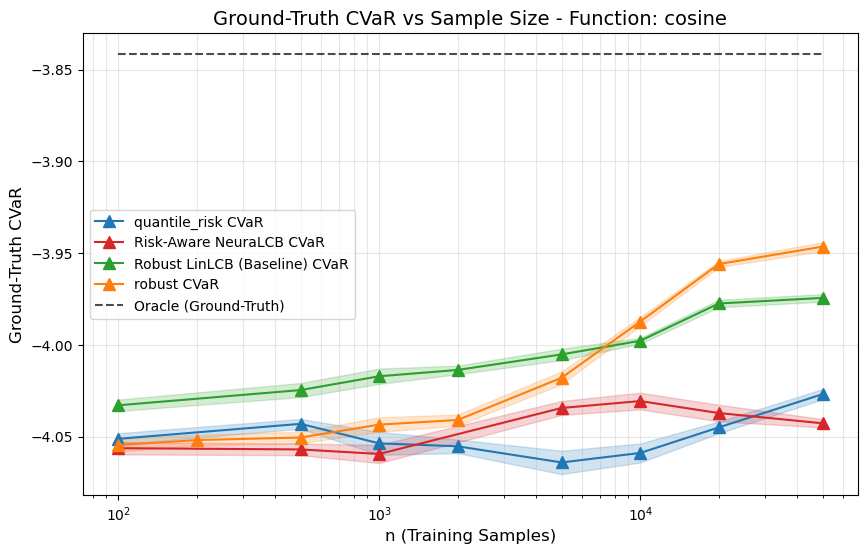

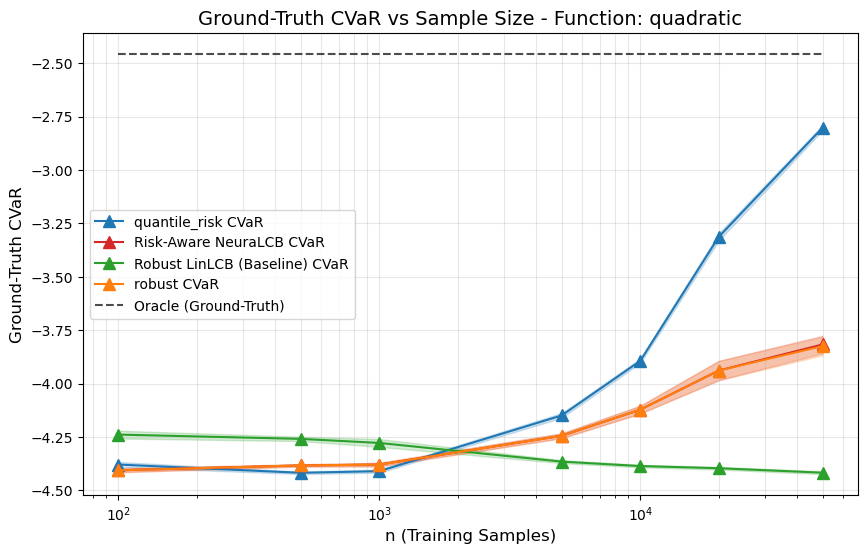

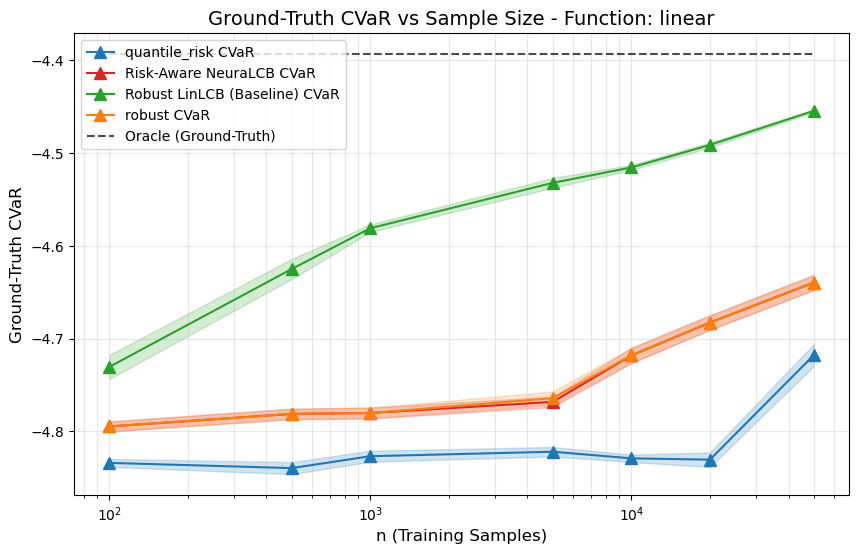

In [9]:
for func_name, summaries in all_function_data.items():
    plt.figure(figsize=(10, 6))
    for algo, summary in summaries.items():
        if not summary['n_extra']: continue
        color = color_map.get(algo, None)
        plt.plot(summary['n_extra'], summary['gt_cvar_mean'], '-^', label=f"{label_map.get(algo, algo)} CVaR", markersize=8, color=color)
        plt.fill_between(summary['n_extra'], 
                         np.array(summary['gt_cvar_mean']) - np.array(summary['gt_cvar_std']), 
                         np.array(summary['gt_cvar_mean']) + np.array(summary['gt_cvar_std']), 
                         alpha=0.2, color=color)

    if summaries:
        first_algo = next(iter(summaries))
        if summaries[first_algo]['n_extra']:
            plt.plot(summaries[first_algo]['n_extra'], summaries[first_algo]['oracle_cvar'], 
                     'k--', label="Oracle (Ground-Truth)", alpha=0.7)

    plt.xscale('log')
    plt.title(f"Ground-Truth CVaR vs Sample Size - Function: {func_name}", fontsize=14)
    plt.xlabel("n (Training Samples)", fontsize=12); plt.ylabel("Ground-Truth CVaR", fontsize=12)
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.show()